#En este notebook aplicaremos las diferentes etapas del pre procesamiento:

1.   Pre procesamiento.
2.   Entrenamiento del algoritmo
3.   Testeo del algoritmo.
4.   Cálculo de las métricas de rendimiento.



In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
%matplotlib inline

In [22]:
df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Definición del problem

Contexto
Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la 2ª causa de muerte a nivel mundial, responsable de aproximadamente el 11% del total de muertes. Este conjunto de datos se utiliza para predecir si es probable que un paciente sume un accidente cerebrovascular en función de los parámetros de entrada como el sexo, la edad, varias enfermedades y el estado de tabaquismo. Cada fila de los datos proporciona información relavante sobre el paciente.

Información de atributos

1) id: identificador único\
2) género: "Masculino", "Femenino" u "Otro"\
3) edad: edad del paciente\
4) hipertensión: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión\
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca\
6) ever_married: "No" o "Sí"\
7) work_type: "hijos", "Govt_jov", "Never_worked", "privado" o "trabajador por cuenta propia"\
8) Residence_type: "Rural" o "Urbano"\
9) avg_glucose_level: nivel promedio de glucosa en sangre\
10) BMI: índice de masa corporal\
11) smoking_status: "anteriormente fumado", "nunca fumado", "fuma" o "Desconocido"*\
12) accidente cerebrovascular: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no











Información del DataSet preliminar.

In [23]:
df.head(100)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2458,Female,78.0,0,0,Yes,Private,Rural,235.63,32.3,never smoked,1
96,35512,Female,70.0,0,0,Yes,Self-employed,Rural,76.34,24.4,formerly smoked,1
97,56841,Male,58.0,0,1,Yes,Private,Rural,240.59,31.4,smokes,1
98,8154,Male,57.0,1,0,Yes,Govt_job,Urban,78.92,27.7,formerly smoked,1


In [24]:
df.shape

(5110, 12)

El DataSet contine 12 atributos y 5110 registros.

In [25]:
df.sample(100)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
697,58767,Female,37.0,0,0,Yes,Private,Urban,91.45,25.8,Unknown,0
4536,59405,Female,68.0,1,0,Yes,Private,Urban,150.74,40.3,Unknown,0
498,21058,Female,15.0,0,0,No,children,Rural,114.53,29.1,Unknown,0
5082,24552,Female,44.0,0,0,Yes,Private,Rural,72.03,37.5,smokes,0
2173,38143,Female,67.0,1,0,Yes,Private,Urban,90.01,34.4,smokes,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5015,50140,Female,44.0,0,0,Yes,Govt_job,Rural,133.24,45.0,smokes,0
163,20426,Female,78.0,1,0,No,Private,Urban,203.87,45.7,never smoked,1
986,46323,Female,2.0,0,0,No,children,Rural,165.11,18.0,Unknown,0
5007,42647,Female,59.0,0,0,Yes,Govt_job,Urban,101.19,29.9,formerly smoked,0


Revisar la contidad de valores nulos del DataFrame, el atributo bmi tiene valores nulos o missing values.


In [26]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Del análisis visual podemos observar las características de la variable objetivo stroke.\
Un 95.1% para los casos que hubo accidente cerebrovascular y un 4.9% para los que no hubo accidente cerebrovascular.\
Por lo tanto, tenemos desbalanceada la variable objetivo, por lo que podemos tener un modelo clasificador que acierte los casos que no hubo accidente cerebrovascular, pero que no sea acertivo en la predicción de casos que hubo accidente cerebrovascular.
Esto lleva a realizar un adecuado preprocesamiento de los datos y aplicar validación cruzada en la etapa de Machine Learning.


In [27]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

I.- Preprocesamiento de los Datos. Limpieza de datos.


1.- Convertir valores string en valores numericos. Utilizando Label encoding y One hot encoding.\
2.- Corregir valores nulos con estrategia KNN imputer.\
3.- Convertir algunas variables continuas en rangos.\
4.- Eliminar caracteristicas innecesarias.








1.- Convertir valores string en valores numéricos:

In [28]:
df.head(100)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2458,Female,78.0,0,0,Yes,Private,Rural,235.63,32.3,never smoked,1
96,35512,Female,70.0,0,0,Yes,Self-employed,Rural,76.34,24.4,formerly smoked,1
97,56841,Male,58.0,0,1,Yes,Private,Rural,240.59,31.4,smokes,1
98,8154,Male,57.0,1,0,Yes,Govt_job,Urban,78.92,27.7,formerly smoked,1


#a. One hot encoder para variable categorica nominal "ever_married".

In [29]:
le1 = preprocessing.LabelEncoder()
data1 = df['ever_married']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['ever_married'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1,0.0,1.0
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,Urban,83.75,NaN,never smoked,0,0.0,1.0
5106,44873,Female,81.0,0,0,1,Self-employed,Urban,125.20,40.0,never smoked,0,0.0,1.0
5107,19723,Female,35.0,0,0,1,Self-employed,Rural,82.99,30.6,never smoked,0,0.0,1.0
5108,37544,Male,51.0,0,0,1,Private,Rural,166.29,25.6,formerly smoked,0,0.0,1.0


In [30]:
# Obtener nombres correctos deseados
new_names = ['no_casado', 'casado']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1,0.0,1.0
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,0.0,1.0


#b. One hot encoder para variable categorica nominal "Residence_type".

In [31]:
le1 = preprocessing.LabelEncoder()
data1 = df['Residence_type']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['Residence_type'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,0,1
0,9046,Male,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0
2,31112,Male,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0
3,60182,Female,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0,0.0,1.0,0.0,1.0
5106,44873,Female,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0,0.0,1.0,0.0,1.0
5107,19723,Female,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0,0.0,1.0,1.0,0.0
5108,37544,Male,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0,0.0,1.0,1.0,0.0


In [32]:
# Obtener nombres correctos deseados
new_names = ['Rural', 'Urban']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban
0,9046,Male,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0
2,31112,Male,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0
3,60182,Female,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0


# c. One hot encoder para variable categorica ordinal "gender".

In [33]:
le1 = preprocessing.LabelEncoder()
data1 = df['gender']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['gender'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,0,1,2
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
5106,44873,0,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
5107,19723,0,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
5108,37544,1,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [34]:
# Obtener nombres correctos deseados
new_names = ['Femenino', 'Masculino', 'Otro']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,Femenino,Masculino,Otro
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0


#d. OneHotencoder para variable categorica ordinal "work_type".

In [35]:
le1 = preprocessing.LabelEncoder()
data1 = df['work_type']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['work_type'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df.head(2000)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,Rural,Urban,Femenino,Masculino,Otro,0,1,2,3,4
0,9046,1,67.00,0,1,1,2,1,228.69,36.6,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.00,0,0,1,3,0,202.21,NaN,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.00,0,1,1,2,0,105.92,32.5,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,60182,0,49.00,0,0,1,2,1,171.23,34.4,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1665,0,79.00,1,0,1,3,0,174.12,24.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,32016,1,71.00,1,0,1,2,0,186.95,33.3,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1996,14287,0,32.00,0,0,1,2,1,68.66,22.6,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1997,60139,0,32.00,0,0,1,3,0,128.72,26.3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1998,2447,0,63.00,0,0,1,2,1,85.04,29.7,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [36]:
# Obtener nombres correctos deseados
new_names = ['gov', 'Never', 'Private', 'Self', 'Children']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,Rural,Urban,Femenino,Masculino,Otro,gov,Never,Private,Self,Children
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [37]:
df = df.drop(columns=['gender', 'ever_married', 'work_type', 'Residence_type'])

In [38]:
df.sample(10)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,Femenino,Masculino,Otro,gov,Never,Private,Self,Children
4061,47271,38.0,0,0,122.83,30.6,Unknown,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1189,2750,73.0,1,1,230.68,37.7,Unknown,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2503,4949,49.0,0,0,96.35,35.9,never smoked,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3291,50455,67.0,0,0,110.41,28.7,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3845,71221,42.0,0,0,99.94,33.4,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1681,52419,66.0,0,0,190.40,NaN,formerly smoked,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1606,32766,51.0,0,0,106.41,41.9,smokes,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4275,50141,5.0,0,0,91.30,20.7,Unknown,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2852,54805,27.0,0,0,73.65,24.8,Unknown,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2085,15873,70.0,0,0,72.56,30.4,formerly smoked,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


e. One hot encoder para variable categorica nominal "smoking_status".

In [39]:
le1 = preprocessing.LabelEncoder()
data1 = df['smoking_status']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['smoking_status'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,...,Otro,gov,Never,Private,Self,Children,0,1,2,3
0,9046,67.0,0,1,228.69,36.6,1,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,2,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,3,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,NaN,2,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5106,44873,81.0,0,0,125.20,40.0,2,0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,19723,35.0,0,0,82.99,30.6,2,0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,37544,51.0,0,0,166.29,25.6,1,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [40]:
# Obtener nombres correctos deseados
new_names = ['Desc', 'Antf', 'Nuncaf', 'Fuma']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.6,1,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,2,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,3,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [41]:
df = df.drop(columns=['smoking_status'])

In [42]:
df

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,no_casado,casado,Rural,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,1,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,NaN,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5106,44873,81.0,0,0,125.20,40.0,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,19723,35.0,0,0,82.99,30.6,0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,37544,51.0,0,0,166.29,25.6,0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


2.- Corregir valores nulos con estrategia KNN imputer, variable "bmi"

a. Con tres vecinos.

In [43]:
knn_imputer = KNNImputer(n_neighbors=3, weights="uniform")

In [44]:
df[['bmi']] = knn_imputer.fit_transform(df[['bmi']])


In [45]:
df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,no_casado,casado,Rural,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.600000,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,28.893237,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.500000,1,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.400000,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.000000,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0



b. Con cinco vecinos.



In [46]:
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")

In [47]:
df[['bmi']] = knn_imputer.fit_transform(df[['bmi']])

In [48]:
df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,no_casado,casado,Rural,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.600000,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,28.893237,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.500000,1,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.400000,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.000000,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Se seleciona cinco vecinos y se comprueba la existecia de missing value.

In [49]:
df.isnull().sum()

id                   0
age                  0
hypertension         0
heart_disease        0
avg_glucose_level    0
bmi                  0
stroke               0
no_casado            0
casado               0
Rural                0
Urban                0
Femenino             0
Masculino            0
Otro                 0
gov                  0
Never                0
Private              0
Self                 0
Children             0
Desc                 0
Antf                 0
Nuncaf               0
Fuma                 0
dtype: int64

3.- Convertir algunas variables continuas en rangos.

a. Convertir algunas variables continuas en rangos. "bmi".

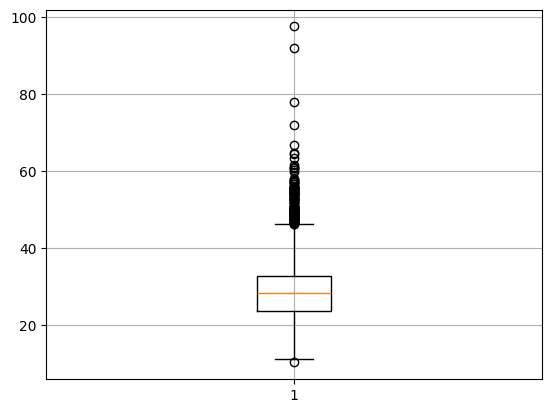

In [50]:
plt.grid()
plt.boxplot(list(df['bmi']))
plt.show()

b. Convertir algunas variables continuas en rangos. "age".

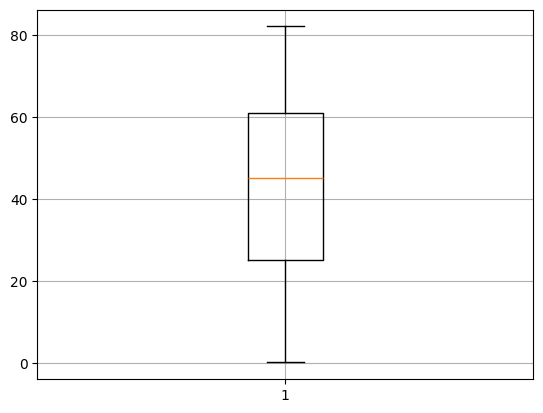

In [51]:
plt.grid()
plt.boxplot((df['age']))
plt.show()

Analizando el avg_glucose_level

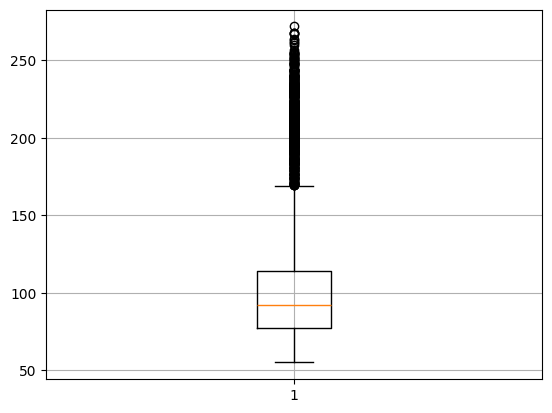

In [52]:
plt.grid()
plt.boxplot(list(df['avg_glucose_level']))
plt.show()

In [53]:
Y = df['stroke']

In [54]:
X = df.drop(columns=['stroke'])

In [55]:
X = StandardScaler().fit_transform(X)

In [56]:
df_X_Scaler = pd.DataFrame(X)

In [57]:
df_X_Scaler.describe()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,...,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03
mean,-1.181920e-16,5.005781e-17,-4.727682e-17,5.561978e-18,1.001156e-16,2.224791e-17,6.118176e-17,-6.118176e-17,-9.733462e-18,-9.177264e-17,...,-8.342968e-18,3.059088e-17,-1.042871e-17,-1.529544e-16,-6.396275e-17,-1.390495e-18,-4.727682e-17,3.615286e-17,-6.396275e-17,-3.754335e-17
std,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,...,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.722657e+00,-1.908261e+00,-3.286019e-01,-2.389468e-01,-1.126958e+00,-2.415564e+00,-7.238842e-01,-1.381436e+00,-9.840797e-01,-1.016178e+00,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
25%,-8.873766e-01,-8.061152e-01,-3.286019e-01,-2.389468e-01,-6.383223e-01,-6.616944e-01,-7.238842e-01,-1.381436e+00,-9.840797e-01,-1.016178e+00,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
50%,1.957360e-02,7.843218e-02,-3.286019e-01,-2.389468e-01,-3.149945e-01,-6.407951e-02,-7.238842e-01,7.238842e-01,-9.840797e-01,9.840797e-01,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
75%,8.584343e-01,7.860701e-01,-3.286019e-01,-2.389468e-01,1.754080e-01,5.075521e-01,1.381436e+00,7.238842e-01,1.016178e+00,9.840797e-01,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,1.519732e+00,-4.576761e-01,1.304165e+00,-4.273133e-01
max,1.721303e+00,1.714845e+00,3.043196e+00,4.185032e+00,3.657145e+00,8.926127e+00,1.381436e+00,7.238842e-01,1.016178e+00,9.840797e-01,...,7.147727e+01,2.603417e+00,1.520765e+01,8.642966e-01,2.288955e+00,2.537348e+00,1.519732e+00,2.184951e+00,1.304165e+00,2.340204e+00


In [58]:
from sklearn.model_selection import train_test_split
seed = 0
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = seed)